# **Assessment 1**

For our first assessment, our goal is to solve an imputation problem: we will create a neural network architecture that learns how to recover missing portions of an image.

This is an important problem in magnetic resonance imaging (MRI), where patient scans are often limited to a few areas to avoid lengthy scanning times.

In particular, we are going to focus on images of human heads. We have managed to gain access to one hundred images of patient's heads but, unfortunately, these images have a significant portion of missing information. Your goal during the assessment is to design a neural network that can recover these missing portions.

<br>

---

<br>

We do not have access to the labels for the images we want to recover, so we will have to be a bit creative to obtain a workable dataset on which to train our neural network.

Fortunately for us, we have access to a generative model that has been trained to produce realistic-looking MRI images of patient's heads. Using this model, you will create an appropriate dataset to train your architecture. We have provided you with the basic setup code to start using this generative model in **Question 1** below.

The corrupted images that we want to recover are contained in the numpy file `test_set.npy` of this repository. The file contains 100 patient images with a size of 64x64 pixels.

The architecture that you design in this assessment should use the artificially-generated dataset in order to recover the missing information in the images contained in `test_set.npy`.

<br>

All answers to the assessment should be contained within the structure below, but you are free to add new code and text cells as required to your answers. Read the text for each question and follow the instructions carefully. Answers that do not follow this structure will not be marked. **Do NOT change the name of this file.**

Please, **make sure to execute all your cells and save the result of the execution**. We will only mark cells that have been executed and will not execute any cells ourselves.

<br>

---

<br>

<br><br>

## **Question 1**  (25%)

Using the provided image-generation network, create a dataset of brain images that will later be used to train your chosen architecture.

Given that you will likely want to use this dataset multiple times during training, we recommend that you save the generated images to an appropriate folder in your GDrive.

Once you have generated your dataset, load and display ten of your generated images here.

We have also provided you with some corrupted images in the file `test_set.npy` of this repository. You should also load and display ten of these corrupted images here.

Below, we have provided template code, including some required downloads and installations, so that you can easily use the trained generative model. Sample generation in this model is done using the function `generate`, and is controlled by some input arguments. It is your job to figure out a sensible set of parameters that will produce images that are useful for the requirements of your task.

<br>

## load data

In [1]:
import os
import sys

In [2]:
# Pull and install necessary files
from google.colab import drive
drive.mount('/content/drive')

# INSTRUCTIONS:
# Open in a BROWSER https://drive.google.com/file/d/1I8Ry7Z_QqnlARwOuDgN4NPCd-GcLw1OC/view?usp=drive_link
# Download the file cw1_files.zip
# Go to https://drive.google.com/ and log in with the account you will be using for this coursework
# In the folder 'My Drive' upload cw1_files.zip (DO NOT UNZIP THE FILE)
# Run the following:

!unzip /content/drive/MyDrive/cw1_files.zip -d ./
!chmod +x run.sh
!bash ./run.sh
sys.path.append('/content/ese-invldm')

Mounted at /content/drive
Archive:  /content/drive/MyDrive/cw1_files.zip
  inflating: ./files/config_training.yml  
  inflating: ./run.sh                
  inflating: ./ese-invldm/setup.py   
  inflating: ./files/default_config.yml  
  inflating: ./ese-invldm/ese_invldm/ese_invldm.py  
  inflating: ./ese-invldm/ese_invldm/__init__.py  
  inflating: ./files/autoencoder/autoencoder_ckpt_latest.pth  
  inflating: ./files/diffusion/diffusion_ckpt_latest.pth  
Cloning the repository from https://github.com/dpelacani/InverseLDM.git...
Cloning into 'InverseLDM'...
remote: Enumerating objects: 1331, done.
remote: Counting objects: 100% (261/261), done.
remote: Compressing objects: 100% (161/161), done.
remote: Total 1331 (delta 167), reused 182 (delta 100), pack-reused 1070 (from 1)
Receiving objects: 100% (1331/1331), 467.16 KiB | 19.46 MiB/s, done.
Resolving deltas: 100% (875/875), done.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 4.1 M

In [76]:
from ese_invldm import generate

"""
Generates samples using a diffusion-based generative model.

This function leverages a pre-configured diffusion model to produce synthetic samples.
The sampling process supports adjustable parameters for total samples, inference steps, and batch size.
A scheduler and temperature can also be configured to control the sampling behaviour.

Parameters:
    num_samples (int):
        Total number of samples to generate.
    num_inference_steps (int):
        Number of diffusion inference steps.
        The minimum number of steps is 1, but we recommend exploring the range from 10 to 50.
        Please note that more steps will increase quality but also the computational cost. Be careful not
        to burn through your credits by using a very large number of steps!
    batch_size (int):
        Number of samples to process in each batch during sampling.
    scheduler (str, optional):
        Sampling scheduler to use (e.g., "ddim", "ddpm"). You can quickly test which one provides the most appropriate results
        for this task.
    temperature (float, optional):
        Sampling temperature to control randomness, given as a number between 0 and 1. Higher values produce more diverse outputs.
    seed (int, optional):
        Random seed for reproducibility. Defaults to 42.

Returns:
    list:
        A list containing the batches of generated samples, where each sample
        corresponds to a single data instance produced by the diffusion model.

"""

samples = generate(
    num_samples=3200,
    num_inference_steps=20,#
    batch_size=64,
    scheduler="ddim",
    temperature=0.8,
    seed=86
)

/content/InverseLDM/invldm/runners/base_runner.py:137: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_states = torch.load(path)


Batch 0


100%|██████████| 20/20 [00:02<00:00,  8.09it/s]


Batch 1


100%|██████████| 20/20 [00:02<00:00,  8.20it/s]


...

100%|██████████| 20/20 [00:02<00:00,  8.20it/s]


Batch 48


100%|██████████| 20/20 [00:02<00:00,  8.19it/s]


Batch 49


100%|██████████| 20/20 [00:02<00:00,  8.19it/s]


In [4]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Save the image to google drive:**



In [77]:
import numpy as np
generated_samples = np.array([sample.cpu().numpy() for sample in samples])

np.save("/content/drive/My Drive/generated_sample.npy", generated_samples)



## Show the first generated images:

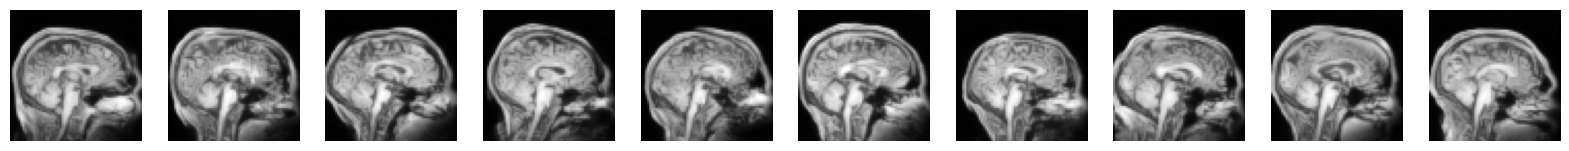

In [78]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_samples(samples, num_images=10):
    """
    Plots the first image from the first `num_images` batches in the samples list.

    Parameters:
        samples (list of arrays or tensors): A list where each item is a batch of images.
        num_images (int): Number of batches to display the first image from.

    Assumes that each batch contains images in a format suitable for direct plotting (e.g., tensors).
    """
    fig, axes = plt.subplots(1, num_images, figsize=(20, 4))  # Create a row of subplots

    for i, ax in enumerate(axes):
        if i >= len(samples):
            break
        img = samples[i][0]  # Get the first image from the i-th batch

        # Convert to numpy if it's a Tensor
        if isinstance(img, torch.Tensor):
            img = img.cpu().numpy()  # Ensure it's moved to CPU before converting

        # Rescale if the values are from -1 to 1
        if img.min() < 0:
            img = (img + 1) / 2  # Rescale to [0, 1]

        # Remove channel dimension if it's grayscale
        if img.shape[0] == 1:  # CHW format and 1 channel
            img = img.squeeze(0)  # Remove channel dimension

        # Display the image
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.axis('off')  # Turn off axis

    plt.show()

# Assuming `samples` is a list where each element is a batch of images as tensors with shape (batch_size, channels, height, width)
plot_samples(samples, num_images=10)


I tried number of samples from 100 to 300 to 640 to 6400
try batch size from 10 to 30 to 64,
temperature from 0.6 to 0.7 to 0.9,
try number of inference steps from 10 to 20 to 30
adapt DDIM and DDPM. I can see that the images are more clealy.And in Question 3, because of the blur, I increase parameter size.

## Show first 10 test_set images:

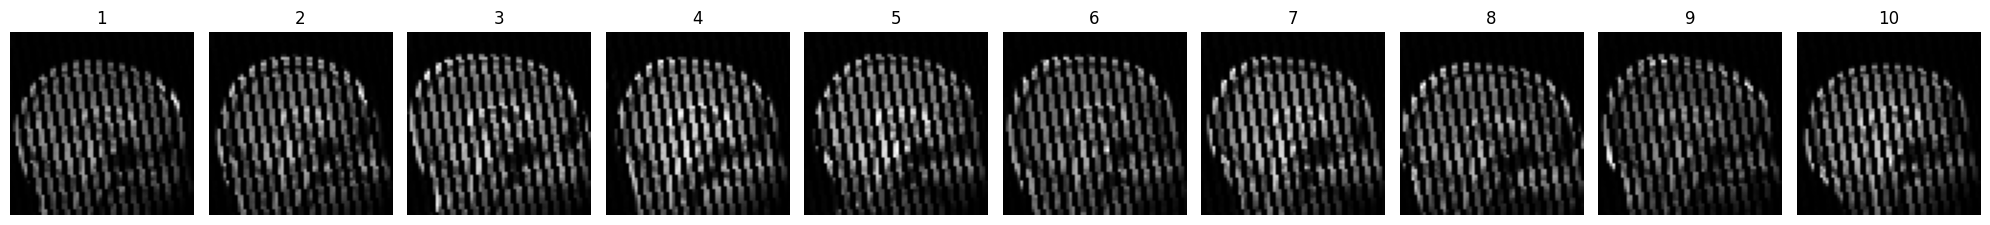

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# load data
data = np.load('/content/drive/MyDrive/dl-module-coursework-1-esemsc-f8af2eba/test_set.npy')

# create figure
fig, axes = plt.subplots(1, 10, figsize=(20, 5))  # 一行 10 张图像，调整 figsize 以控制图像大小

# 显示前 10 张图像
for i in range(10):
    image = data[i].squeeze()  # 去掉形状为 (1, 64, 64) 中的通道维度
    axes[i].imshow(image, cmap='gray')  # 显示灰度图
    axes[i].axis('off')  # 去掉坐标轴
    axes[i].set_title(f"{i+1}")  # 可选：设置图像标题

# 调整布局以避免重叠
plt.tight_layout()
plt.show()


<br>

---

<br>

## **Question 2**  (25%)

Using the data generated in **Question 1**, create a PyTorch `TensorDataset` and a `DataLoader` for the training set.

Using the provided corrupted images inside `test_set.npy`, create another `TensorDataset` and a `DataLoader` for the test set.

The training dataset should provide batches of brain images generated in **Question 1** and should corrupt these images appropriately so that they resemble images in the test set. The dataset should also pair each image with its corresponding un-corrupted image as a label.

The test dataset should provide the corrupted images provided, for which no labels are available.

Display here ten images of your training dataset and ten images of your test dataset, and their corresponding labels when available.

<br>



## load data

In [32]:

generated_sample = np.load('/content/drive/MyDrive/generated_sample.npy')
test_data = np.load('/content/drive/MyDrive/dl-module-coursework-1-esemsc-f8af2eba/test_set.npy')

## Corruped images and corresponding original images

In [33]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt

class BrainImagesDataset(Dataset):
    def __init__(self, generated_sample, split="train", stripe_width=5, angle=15, opacity=0.5, transform=None):
        if isinstance(generated_sample, np.ndarray):
          generated_sample = torch.from_numpy(generated_sample).float()
        self.split = split
        self.transform = transform
        self.stripe_width = stripe_width
        self.angle = angle
        self.opacity = opacity
        self.generated_sample = generated_sample.view(-1, 1, 64, 64)  # Add channel dimension properly

    def _get_mask(self, img_shape):
      c, h, w = img_shape
      mask = torch.ones((c, h, w))  # Start with a fully visible image

      stripe_width = 4  # Adjust width of each stripe to match the pattern in the example
      space_between_stripes = 2  # Space between stripes could be adjusted as needed
      opacity = 0  # Ensure full transparency for the stripes

      # Calculate horizontal offsets more accurately
      offset_per_row = 1  # Adjust this to change how the stripes align from row to row

      for row in range(h):
          offset = (row * offset_per_row) % (stripe_width + space_between_stripes)
          for col in range(offset, w, stripe_width + space_between_stripes):
              start_col = col
              end_col = min(col + stripe_width, w)
              mask[:, row, start_col:end_col] *= opacity  # Apply the transparency

      # Adjust tilt angle
      tilt_angle = -30  # Less steep angle

      # Rotate the mask by the tilt angle
      if tilt_angle != 0:
          from scipy.ndimage import rotate
          mask = torch.tensor(rotate(mask.numpy(), angle=tilt_angle, axes=(1, 2), reshape=False, mode='nearest'), dtype=torch.float32)

      return mask

    def __getitem__(self, idx):
        img = self.generated_sample[idx]

        if self.transform:
            img = self.transform(img)

        if self.split == "train":
            # label = self.labels[idx]
            mask = self._get_mask(img.shape)
            corrupted_img = img * mask
            return corrupted_img,img
        else:
            return img,torch.zeros(1)  # No labels in test set

    def __len__(self):
        return len(self.generated_sample)

    def __str__(self):
        class_string = f"{self.__class__.__name__}\n\tLength: {self.__len__()}"
        for key, value in self.__dict__.items():
            if key != "data":
                class_string += f"\n\t{key}: {value}"
        return class_string


# Transformations (if any)
transform = transforms.Compose([
    # transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Create datasets
train_dataset = BrainImagesDataset(generated_sample, split="train")
test_dataset = BrainImagesDataset(test_data, split="test")

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)



Displaying Training Set Images:


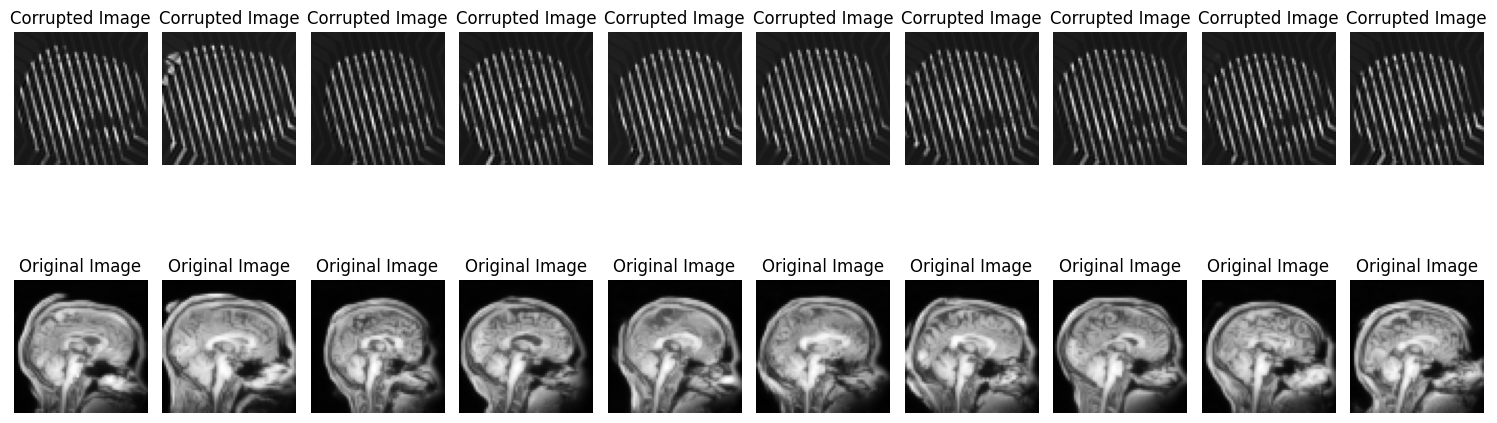

Displaying Test Set Images:


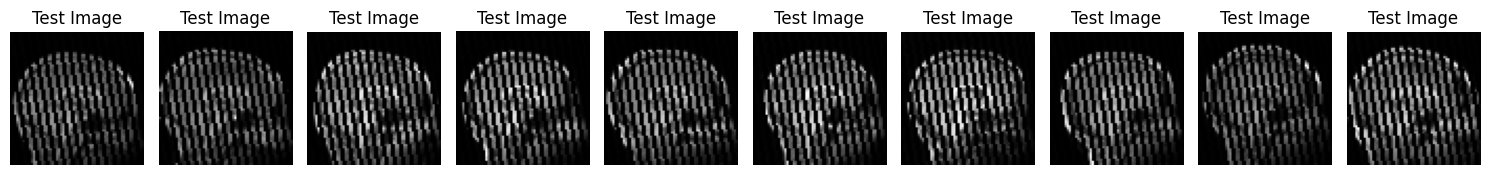

In [27]:
import matplotlib.pyplot as plt

def show_images(loader, num_images=10, dataset_type="train"):
    if dataset_type == "train":
        # For the training data, display corrupted and original images.
        fig, axs = plt.subplots(2, num_images, figsize=(15, 6))  # 2 rows for corrupted and original
        for idx, (corrupted, original) in enumerate(loader):
            if idx >= num_images:
                break
            axs[0, idx].imshow(corrupted[0, 0].cpu().numpy(), cmap='gray')
            axs[0, idx].axis('off')
            axs[0, idx].set_title('Corrupted Image')

            axs[1, idx].imshow(original[0, 0].cpu().numpy(), cmap='gray')
            axs[1, idx].axis('off')
            axs[1, idx].set_title('Original Image')
    elif dataset_type == "test":
        # For the test data, display only the corrupted images as no original is available.
        fig, axs = plt.subplots(1, num_images, figsize=(15, 3))  # 1 row for test images
        for idx, (corrupted, _) in enumerate(loader):
            if idx >= num_images:
                break
            axs[idx].imshow(corrupted[0, 0].cpu().numpy(), cmap='gray')
            axs[idx].axis('off')
            axs[idx].set_title('Test Image')

    plt.tight_layout()
    plt.show()

# Assuming train_loader and test_loader are properly defined and initialized
print("Displaying Training Set Images:")
show_images(train_loader, num_images=10, dataset_type="train")
print("Displaying Test Set Images:")
show_images(test_loader, num_images=10, dataset_type="test")


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Version 2:

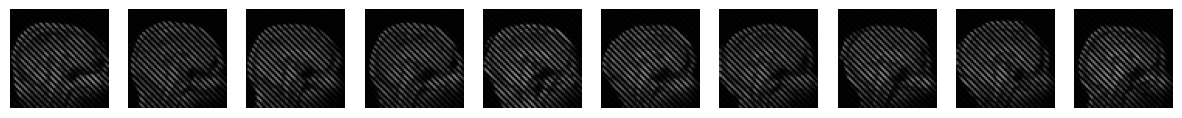

In [64]:
def plot_test_images(test_images, num_images=10):
    """
    Display test images in a single row.

    Parameters:
        test_images (numpy array): Array of test images to display.
        num_images (int): Number of images to display.
    """
    num_images = min(num_images, len(test_images))
    plt.figure(figsize=(15, 5))

    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(test_images[i], cmap='gray', vmin=0, vmax=255)
        plt.title(f"Test Image {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
def create_mask(img_size):
    rectangle_width = 2
    rectangle_height = 6
    shift_per_row = 1
    image = np.ones((img_size, img_size))
    for y in range(0, img_size, rectangle_height):
        start_x = (y // rectangle_height) * shift_per_row
        for x in range(start_x, img_size, rectangle_width * 2):
            image[y:y+rectangle_height, x:x+rectangle_width] = 0
    return image

# 应用遮罩到所有图片
def apply_mask_to_images(image_paths, mask):
    masked_images = []
    for path in image_paths:
        img = Image.open(path).convert('L')  # 将图片转换为灰度图
        img_array = np.array(img)
        masked_image = img_array * mask  # 应用遮罩
        masked_images.append(Image.fromarray(masked_image))
    return masked_images

# 主执行部分
img_size = 64  # 假设所有图片都是 64x64
mask = create_mask(img_size)
masked_images = apply_mask_to_images(generated_sample, mask)

# 保存或展示遮罩后的图片
for i, img in enumerate(masked_images):
    img.save(f'masked_image_{i}.png')  # 保存到文件
    img.show()  # 展示图片

<br>

---

<br>

## **Question 3** (50%)

Using the dataset created in **Question 2**, design and train an architecture to recover the missing image lines of the provided test dataset.

Once you have trained your architecture, display here ten images of the test set with the recovered lines filled in.

Additionally, save the test data with the missing values filled in into a numpy file called `test_set_nogaps.npy`. These images should be **in the same order** as those in the `test_set.npy` file and should have the same pixel size of 64x64. **Any images not contained in the `test_set_nogaps.npy` file or incorrectly ordered will not be marked.**

You have freedom to choose an architecture that you consider appropriate to solve this problem. However, you will need to train your chosen architecture as part of the assessment: **pre-trained networks are not allowed**.

You will be assessed by the quality of your predictions of the missing data values and additional marks will be given for originality in your network design choices. You should include, as part of your answer, a paragraph explaining the architecture you have chosen and any additional design choices and hyperparameters that have been important to build your solution.

This is an open-book assessment and you are encouraged to use resources online, including  tools like chatGPT. However, make sure to always mention the sources for your code and ideas, including websites, papers, and tools like chatGPT.

<br>


<br>

---

<br>

# **VAEs**

100%|██████████| 10/10 [00:01<00:00,  5.68it/s]


Epoch 1, Loss: 0.89823577105999


100%|██████████| 10/10 [00:01<00:00,  5.76it/s]


Epoch 2, Loss: 0.06829989869147539


100%|██████████| 10/10 [00:01<00:00,  5.44it/s]


...

Epoch 98, Loss: 0.005800802120938897


100%|██████████| 10/10 [00:01<00:00,  5.02it/s]


Epoch 99, Loss: 0.005786967230960727


100%|██████████| 10/10 [00:01<00:00,  5.28it/s]


Epoch 100, Loss: 0.005565872276201844


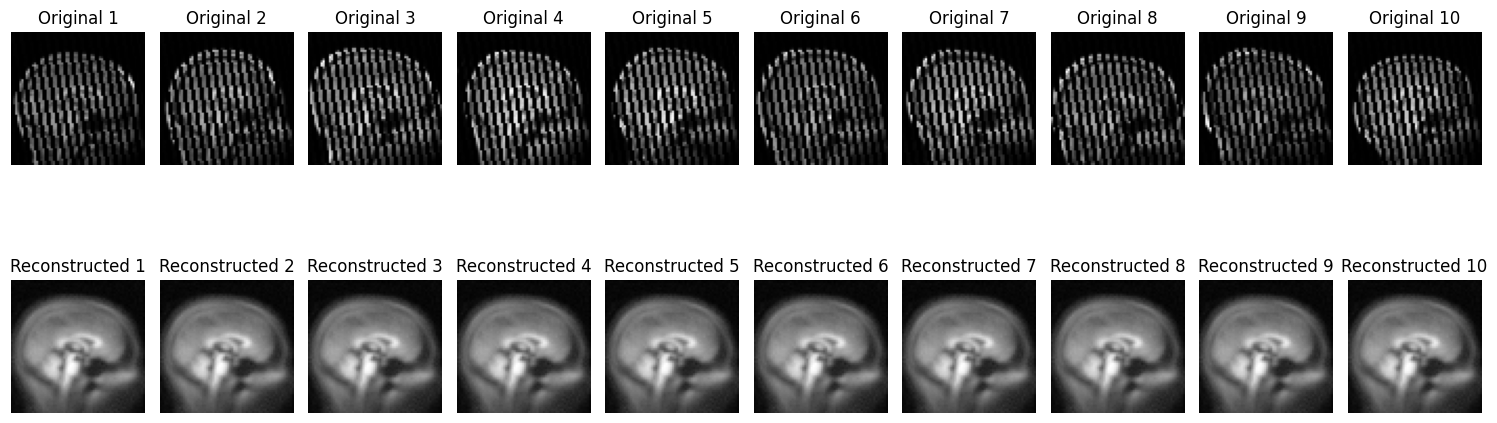

In [32]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms, datasets
from tqdm import tqdm

# Define the VAE components
class VAE(nn.Module):
    def __init__(self, latent_dims):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(64*64, 400),
            nn.ReLU(),
            nn.Linear(400, latent_dims*2)  # Output both mu and sigma
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dims, 400),
            nn.ReLU(),
            nn.Linear(400, 64*64),
            nn.Sigmoid()  # Ensure output is between 0 and 1
        )

    def forward(self, x):
        x = x.view(-1, 64*64)
        latent_params = self.encoder(x)
        mu = latent_params[:, :latent_dims]
        sigma = torch.exp(latent_params[:, latent_dims:])  # Sigma must be positive
        z = mu + sigma * torch.randn_like(sigma)
        x_recon = self.decoder(z)
        x_recon = x_recon.view(-1, 1, 64, 64)
        kl_div = -0.5 * torch.sum(1 + torch.log(sigma**2) - mu**2 - sigma**2)
        return x_recon, kl_div

    def reconstruct(self, x):
        with torch.no_grad():
            x = x.view(-1, 64*64)
            latent_params = self.encoder(x)
            mu = latent_params[:, :latent_dims]
            z = mu  # Use the mean for reconstruction to avoid randomness
            x_recon = self.decoder(z)
            return x_recon.view(-1, 1, 64, 64)

# Load data and prepare DataLoader
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Example normalization, adjust as needed
])

# # Dummy dataset, replace with your actual dataset
# dataset = datasets.MNIST(root='.', train=True, transform=transform, download=True)
# train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Initialize model, optimizer, and set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
latent_dims = 10
vae = VAE(latent_dims).to(device)
optimizer = optim.Adam(vae.parameters(), lr=0.001)

# Training loop
def train_vae(vae, data_loader, epochs=10):
    vae.train()
    for epoch in range(epochs):
        total_loss = 0
        for corrupted_images, original in tqdm(data_loader):
            corrupted_images = corrupted_images.to(device)
            original = original.to(device)
            optimizer.zero_grad()
            recon_images, kl_div = vae(corrupted_images)
            loss = ((original - recon_images)**2).mean() + kl_div  # MSE loss + KL divergence
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f'Epoch {epoch+1}, Loss: {total_loss/len(data_loader)}')

train_vae(vae, train_loader, epochs=100)

# Generate and save reconstructed images
test_images, _ = next(iter(test_loader))
test_images = test_images.to(device)
reconstructed = vae.reconstruct(test_images)
reconstructed = reconstructed.cpu().numpy()

# Save images as a numpy file
np.save('test_set_nogaps.npy', reconstructed)

# Assuming `corrupted_images` and `reconstructed` are lists or tensors of images
# Ensure these variables are correctly populated with the corresponding image data prior to using this snippet

# Display some of the reconstructed images alongside the corrupted images for comparison
def plot_reconstructions(original_images, reconstructed_images, num_images=10):
    """
    Plot a comparison of original and reconstructed images.

    Args:
    original_images (Tensor or array): The original images from the dataset.
    reconstructed_images (Tensor or array): The images reconstructed by the VAE.
    num_images (int): Number of images to display.
    """
    # Check if the tensors are on GPU and move them to CPU if necessary
    if torch.is_tensor(original_images) and original_images.is_cuda:
        original_images = original_images.cpu().numpy()
    elif not isinstance(original_images, np.ndarray):
        original_images = original_images.numpy()  # Convert to numpy if it's not already

    if torch.is_tensor(reconstructed_images) and reconstructed_images.is_cuda:
        reconstructed_images = reconstructed_images.cpu().numpy()
    elif not isinstance(reconstructed_images, np.ndarray):
        reconstructed_images = reconstructed_images.numpy()  # Convert to numpy if it's not already

    fig, axes = plt.subplots(2, num_images, figsize=(15, 6))  # 2 rows and 'num_images' columns
    for i in range(num_images):
        # Original Images
        ax = axes[0, i]
        ax.imshow(original_images[i].squeeze(), cmap='gray')
        ax.set_title("Original {}".format(i + 1))
        ax.axis('off')

        # Reconstructed Images
        ax = axes[1, i]
        ax.imshow(reconstructed_images[i].squeeze(), cmap='gray')
        ax.set_title("Reconstructed {}".format(i + 1))
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Assuming you retrieve these from somewhere after processing
# These should be tensors if coming directly from PyTorch model output
original_images = test_images  # PyTorch Tensor
reconstructed = vae.reconstruct(test_images)  # This should be a PyTorch Tensor

# Use the function to plot
plot_reconstructions(original_images, reconstructed, num_images=10)



Seems like model collapes.

# **U-net**

  1%|          | 2/320 [00:00<00:55,  5.73it/s]

Epoch [1/10], Loss: 0.0886
Epoch [1/10], Loss: 0.0904


  1%|▏         | 4/320 [00:00<00:55,  5.74it/s]

Epoch [1/10], Loss: 0.0813
Epoch [1/10], Loss: 0.0803


  2%|▏         | 6/320 [00:01<00:54,  5.76it/s]

...

Epoch [10/10], Loss: 0.0020
Epoch [10/10], Loss: 0.0019


100%|█████████▉| 319/320 [00:56<00:00,  5.74it/s]

Epoch [10/10], Loss: 0.0018
Epoch [10/10], Loss: 0.0017


100%|██████████| 320/320 [00:56<00:00,  5.66it/s]


Epoch [10/10], Loss: 0.0017


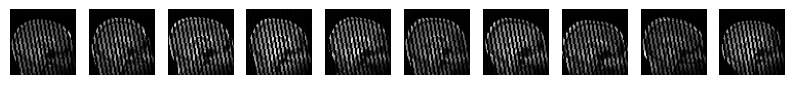

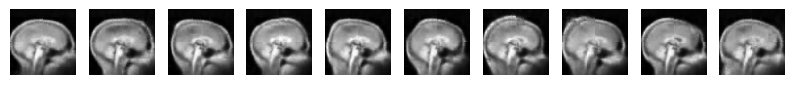

In [87]:
import torch
from torch import nn, optim
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

# Define a simple U-net model
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        # Encoder part of the U-net: two convolutional layers with ReLU and max pooling
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),  # First conv layer: 1 input channel, 16 output channels
            nn.BatchNorm2d(16),
            nn.ReLU(),  # Activation function to introduce non-linearity
            nn.MaxPool2d(kernel_size=2, stride=2),  # Pooling to reduce spatial dimensions
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),  # Second conv layer: 16 input channels, 32 output channels
            nn.BatchNorm2d(32),
            nn.ReLU(),  # Activation function
            nn.MaxPool2d(kernel_size=2, stride=2),  # Pooling layer
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Second conv layer: 16 input channels, 32 output channels
            nn.BatchNorm2d(64),
            nn.ReLU(),  # Activation function
            nn.MaxPool2d(kernel_size=2, stride=2),  # Pooling layer
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),  # Second conv layer: 16 input channels, 32 output channels
            nn.BatchNorm2d(128),
            nn.ReLU(),  # Activation function
            nn.MaxPool2d(kernel_size=2, stride=2),  # Pooling layer
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),  # Second conv layer: 16 input channels, 32 output channels
            nn.BatchNorm2d(256),
            nn.ReLU(),  # Activation function
            nn.MaxPool2d(kernel_size=2, stride=2)  # Pooling layer
        )
        # Decoder part of the U-net: transpose convolutions to upscale the feature maps
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),  # Upscale and increase feature map detail
            nn.ReLU(),  # Activation function
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),  # Upscale and increase feature map detail
            nn.ReLU(),  # Activation function
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),  # Upscale and increase feature map detail
            nn.ReLU(),  # Activation function
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),  # Upscale and increase feature map detail
            nn.ReLU(),  # Activation function
            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),  # Restore to original dimensions
            nn.Sigmoid()  # Sigmoid to output probabilities (ideal for binary segmentation)
        )

    def forward(self, x):
        x = self.encoder(x)  # Pass input through the encoder
        x = self.decoder(x)  # Decode the encoded features
        return x

# Initialize model, optimizer, loss function, and specify device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
criterion = nn.MSELoss()  # Loss function for measuring reconstruction error
optimizer = optim.Adam(model.parameters(), lr=0.002)  # Optimizer for training

# Load and prepare data, applying necessary transformations
transform = ToTensor()  # Transform to convert images to torch.Tensor
# dataset = datasets.MNIST(root='.', download=True, transform=transform)  # MNIST dataset
# dataloader = DataLoader(dataset, batch_size=32, shuffle=True)  # DataLoader to batch and shuffle data

epoch_losses = []
# Training loop
n_epoch = 10
model.train()  # Set model to training mode
for epoch in range(n_epoch):
    running_loss = 0.0  # Variable to accumulate loss for the epoch
    batch_count = 0  # Counter for the number of batches
    for corrupted_images, original in tqdm(train_loader):
        corrupted_images = corrupted_images.to(device)  # Move images to device
        original = original.to(device)  # Move labels to device

        optimizer.zero_grad()  # Clear gradients for this training step

        outputs = model(corrupted_images)  # Forward pass: compute predicted outputs by passing inputs to the model

        loss = criterion(outputs, original)  # Compute loss: how far are we from the target?

        running_loss += loss.item()  # Accumulate the batch loss
        batch_count += 1

        loss.backward()  # Backward pass: compute gradient of the loss with respect to model parameters

        optimizer.step()  # Perform a single optimization step (parameter update)

        avg_loss = running_loss / batch_count
        epoch_losses.append(avg_loss)  # Store the average loss for the epoch

        print(f'Epoch [{epoch+1}/{n_epoch}], Loss: {loss.item():.4f}')  # Log loss

# plt.figure(figsize=(8, 5))
# plt.plot(range(1, n_epoch + 1), epoch_losses, marker='o', linestyle='-', color='b')
# plt.title('Loss vs. Epoch')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.grid(True)
# plt.show()

# Function to display images
def show_images(images, num_images=4):
    fig, axes = plt.subplots(1, num_images, figsize=(10, 3))  # Setup plot
    for i in range(num_images):
        ax = axes[i]
        ax.imshow(images[i].detach().cpu().numpy().squeeze(), cmap='gray')  # Display image
        ax.axis('off')  # Hide axes

    plt.show()  # Show the plot

# Display some original and reconstructed images to verify reconstruction quality
model.eval()  # Set model to evaluation mode
with torch.no_grad():  # Context-manager that disables gradient calculation
    images, _ = next(iter(train_loader))
    images=images.to(device)  # Load a batch of images
    test_images, _ = next(iter(test_loader))
    test_images = test_images.to(device)
    reconstructed_images = model(images)  # Reconstruct images using the model
    show_images(test_images, num_images=10)  # Display original images
    show_images(reconstructed_images, num_images=10)  # Display reconstructed images


# **GANs**

In [88]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
import numpy as np

# Define a simple convolutional GAN for image completion
class Generator(nn.Module):
    def __init__(self, g_input_dim, g_output_dim):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(g_input_dim, 64, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(32, g_output_dim, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

class Discriminator(nn.Module):
    def __init__(self, d_input_dim):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(d_input_dim, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, 7),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x)

# Build model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
G = Generator(1, 1).to(device)  # Assuming grayscale images
D = Discriminator(1).to(device)

# Define loss function and optimizer
criterion = nn.BCELoss()
optimG = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimD = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Training and testing logic integration
for epoch in range(20):  # Number of epochs
    for real_images, _ in train_loader:  # Assuming images are loaded with shape (batch_size, 1, 64, 64)
        # Train Discriminator
        # ...

        # Train Generator
        # ...

# Saving model predictions on test set
test_images = torch.cat([G(real_images.to(device)) for real_images, _ in test_loader], dim=0).cpu().numpy()
np.save('test_set_nogaps.npy', test_images)

# Show some example outputs
show_images(test_images, num_images=10)


IndentationError: expected an indented block after 'for' statement on line 49 (<ipython-input-88-9dfd5d718645>, line 57)